In [7]:
import cv2
import matplotlib.pyplot as plt
import numpy as np
import dlib
import os

In [8]:
print(os.listdir(".")) #오류로 인한 파일확인

['hero.png', 'image_dark.png', 'image_pro.png', 'CV01.ipynb', 'image_far.png', 'README.md', 'image_rotated.png', 'new_face.jpg', 'king.png', 'image_bright.png', 'cat-whiskers.png', '.ipynb_checkpoints']


In [9]:
#얼굴사진 불러오기
my_image_path = "./new_face.jpg"

img_bgr = cv2.imread(my_image_path)

print(img_bgr.shape)

(1321, 1078, 3)


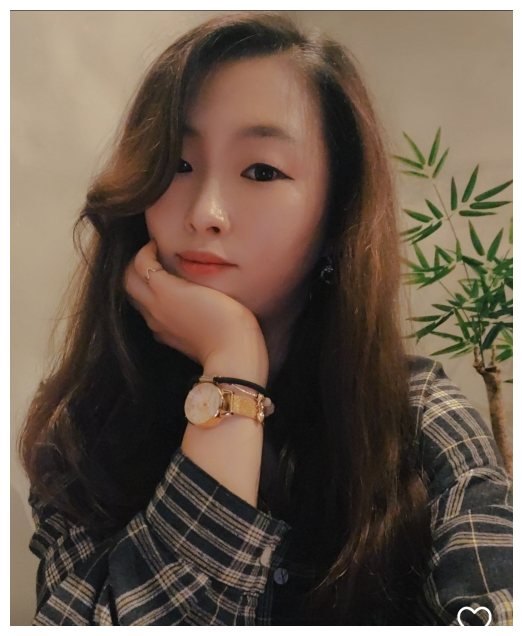

In [18]:
#색상 변환해서 사진확인
img_rgb = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB)

plt.figure(figsize=(8, 8))
plt.imshow(img_rgb)
plt.axis("off")
plt.show()

In [19]:
#얼굴 검출하기
detector_hog = dlib.get_frontal_face_detector()

dlib_rects = detector_hog(img_rgb, 1)

print(dlib_rects)
print("찾은 얼굴 개수:", len(dlib_rects))

rectangles[[(245, 194) (707, 657)]]
찾은 얼굴 개수: 1


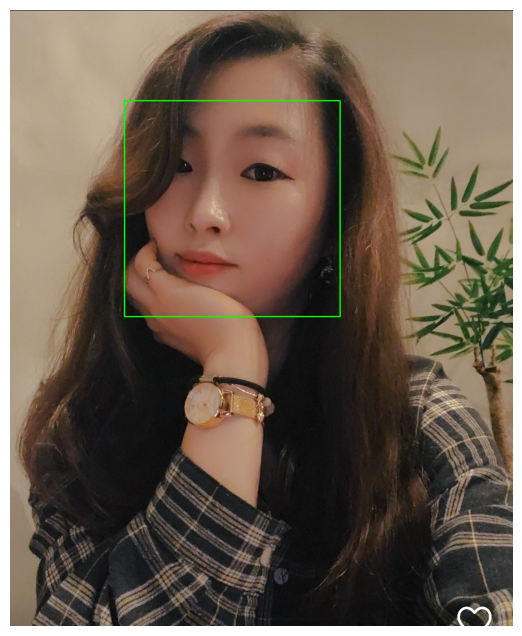

In [21]:
#얼굴박스확인
img_show = img_rgb.copy()

for dlib_rect in dlib_rects:
    left = dlib_rect.left()
    top = dlib_rect.top()
    right = dlib_rect.right()
    bottom = dlib_rect.bottom()

    cv2.rectangle(img_show, (left, top), (right, bottom), (0, 255, 0), 2)

plt.figure(figsize=(8, 8))
plt.imshow(img_show)
plt.axis("off")
plt.show()

In [22]:
#랜드마크 모델 불러오기

model_path = "/home/jovyan/work/camera_sticker/models/shape_predictor_68_face_landmarks.dat"

landmark_predictor = dlib.shape_predictor(model_path)

In [23]:
#랜드마크68개 찾기
list_landmarks = []

for dlib_rect in dlib_rects:
    points = landmark_predictor(img_rgb, dlib_rect)
    list_points = list(map(lambda p: (p.x, p.y), points.parts()))
    list_landmarks.append(list_points)

print("찾은 얼굴 개수:", len(list_landmarks))
print("랜드마크 개수:", len(list_landmarks[0]))
print("앞 5개 좌표:", list_landmarks[0][:5])

찾은 얼굴 개수: 1
랜드마크 개수: 68
앞 5개 좌표: [(289, 369), (280, 414), (276, 460), (278, 506), (286, 550)]


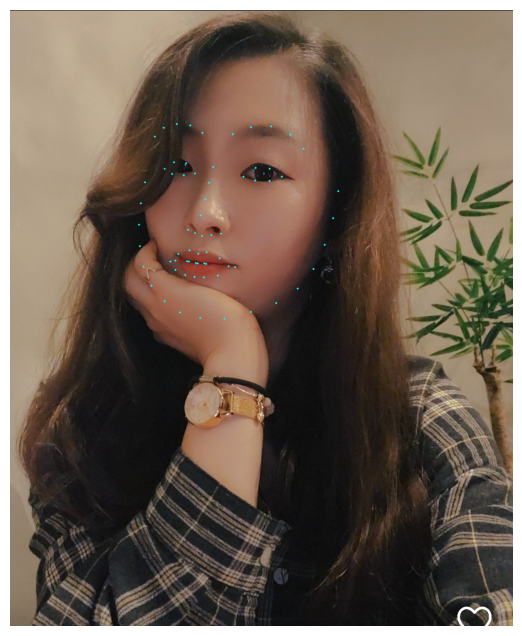

In [24]:
#랜드마크 점 찍어보기
img_show = img_rgb.copy()

for landmark in list_landmarks:
    for point in landmark:
        cv2.circle(img_show, point, 2, (0, 255, 255), -1)

plt.figure(figsize=(8, 8))
plt.imshow(img_show)
plt.axis("off")
plt.show()

In [36]:
#고양이 수염 위치 계산하기
for dlib_rect, landmark in zip(dlib_rects, list_landmarks):
    # 코 끝 좌표: 33번 landmark
    x_nose = landmark[33][0]
    y_nose = landmark[33][1]

    # 얼굴 박스 크기
    w = dlib_rect.width()
    h = dlib_rect.height()

    # 고양이 수염 스티커 크기
    sticker_width = w
    sticker_height = int(w * 0.5)

    # 고양이 수염 위치 계산
    x = x_nose - sticker_width // 2
    y = y_nose - sticker_height // 2 - 20

    #-10 , -20 , -30 (수치변경시 위쪽으로 이동함)

    print("코 끝 위치:", x_nose, y_nose)
    print("얼굴 박스 크기:", w, h)
    print("스티커 위치:", x, y)
    print("스티커 크기:", sticker_width, sticker_height)

코 끝 위치: 411 484
얼굴 박스 크기: 463 464
스티커 위치: 180 349
스티커 크기: 463 231


In [37]:
#고양이 수염 스티커 불러오기

cat_sticker_path = "./cat-whiskers.png"

img_cat_sticker = cv2.imread(cat_sticker_path, cv2.IMREAD_UNCHANGED)

print(img_cat_sticker.shape)

(512, 512, 4)


In [38]:
#수염 스티커  크기 맞추기
img_cat_sticker = cv2.resize(img_cat_sticker, (sticker_width, sticker_height))

print(img_cat_sticker.shape)

(231, 463, 4)


In [39]:
#스티커와 투명도  분리하기
if img_cat_sticker.shape[2] == 4:
    sticker_rgb = img_cat_sticker[:, :, :3]
    sticker_alpha = img_cat_sticker[:, :, 3]
else:
    sticker_rgb = img_cat_sticker
    gray = cv2.cvtColor(img_cat_sticker, cv2.COLOR_BGR2GRAY)
    _, sticker_alpha = cv2.threshold(gray, 250, 255, cv2.THRESH_BINARY_INV)

print("sticker_rgb:", sticker_rgb.shape)
print("sticker_alpha:", sticker_alpha.shape)

sticker_rgb: (231, 463, 3)
sticker_alpha: (231, 463)


In [40]:
#좌표 예외처리하기
img_show = img_bgr.copy()

refined_x = x
refined_y = y

# 왼쪽으로 벗어난 경우
if refined_x < 0:
    sticker_rgb = sticker_rgb[:, -refined_x:]
    sticker_alpha = sticker_alpha[:, -refined_x:]
    refined_x = 0

# 위쪽으로 벗어난 경우
if refined_y < 0:
    sticker_rgb = sticker_rgb[-refined_y:, :]
    sticker_alpha = sticker_alpha[-refined_y:, :]
    refined_y = 0

# 오른쪽으로 벗어난 경우
if refined_x + sticker_rgb.shape[1] > img_show.shape[1]:
    overflow_x = refined_x + sticker_rgb.shape[1] - img_show.shape[1]
    sticker_rgb = sticker_rgb[:, :-overflow_x]
    sticker_alpha = sticker_alpha[:, :-overflow_x]

# 아래쪽으로 벗어난 경우
if refined_y + sticker_rgb.shape[0] > img_show.shape[0]:
    overflow_y = refined_y + sticker_rgb.shape[0] - img_show.shape[0]
    sticker_rgb = sticker_rgb[:-overflow_y, :]
    sticker_alpha = sticker_alpha[:-overflow_y, :]

print("보정된 위치:", refined_x, refined_y)
print("보정된 스티커 rgb 크기:", sticker_rgb.shape)
print("보정된 스티커 alpha 크기:", sticker_alpha.shape)

보정된 위치: 180 349
보정된 스티커 rgb 크기: (231, 463, 3)
보정된 스티커 alpha 크기: (231, 463)


In [41]:
#수염합성하기
sticker_area = img_show[
    refined_y:refined_y + sticker_rgb.shape[0],
    refined_x:refined_x + sticker_rgb.shape[1]
]

mask = sticker_alpha > 0

blended = cv2.addWeighted(sticker_area, 0.3, sticker_rgb, 0.7, 0)

img_show[
    refined_y:refined_y + sticker_rgb.shape[0],
    refined_x:refined_x + sticker_rgb.shape[1]
] = np.where(mask[:, :, np.newaxis], blended, sticker_area)

print("고양이 수염 스티커 적용 완료")

고양이 수염 스티커 적용 완료


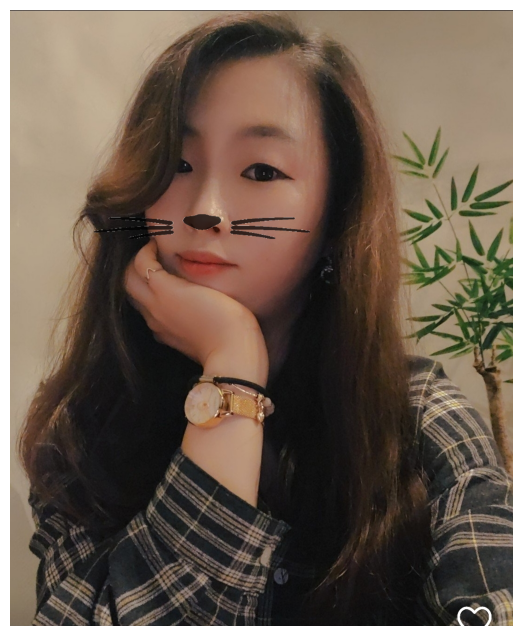

In [42]:
#결과확인하기
# 합성된 이미지 확인하기
img_show_rgb = cv2.cvtColor(img_show, cv2.COLOR_BGR2RGB)

plt.figure(figsize=(8, 8))
plt.imshow(img_show_rgb)
plt.axis("off")
plt.show()

### 스티커 위치가 조금더 위로 가면 좋을듯해서
### 여러번 위치를 수정해 봄

### 회고
새로운 원본 이미지인 `new_face.jpg`에도 고양이 수염 스티커를 적용해보았다. dlib을 이용해 얼굴 영역과 얼굴 랜드마크를 검출한 뒤, 코 주변 좌표를 기준으로 수염 스티커의 위치를 계산하였다. 그 결과 원본 이미지가 바뀌어도 얼굴 위치에 맞춰 스티커가 합성되는 것을 확인할 수 있었다.

다만 새 이미지에서는 머리카락과 손이 얼굴 주변을 일부 가리고 있어 수염 스티커가 왼쪽 부분에서 조금 어색하게 보였다. 또한 얼굴이 완전히 정면이 아니기 때문에 수염이 얼굴 각도에 맞춰 회전하지 않고 수평으로 붙는 한계가 있었다. 이를 통해 다양한 원본 이미지에 적용할 때는 얼굴 각도, 머리카락이나 손에 의한 가림, 이미지 밝기 등이 스티커 위치와 자연스러움에 영향을 준다는 점을 확인하였다.


1차시도 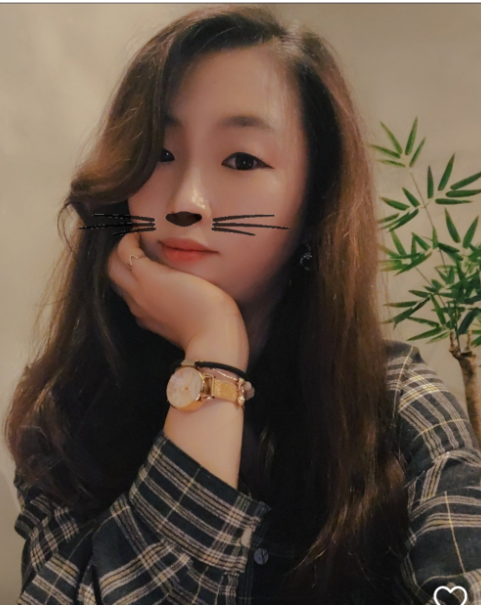

2차시도
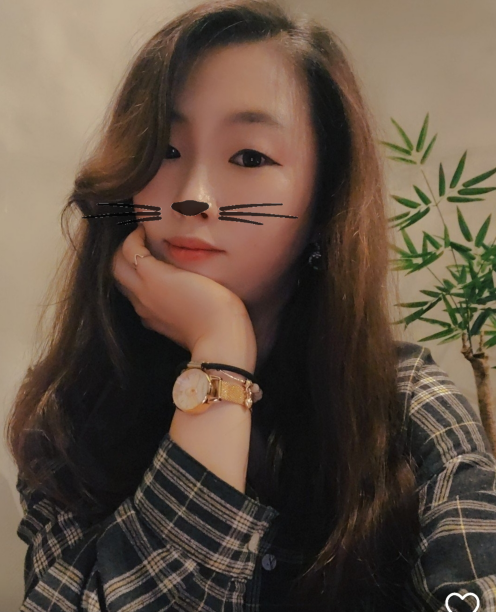
